# ❤️ Heart Disease Prediction — Full ML Pipeline
> **Covers:** Data loading · EDA · Missing-value handling · Encoding & Scaling · Multi-model evaluation · Hyperparameter tuning · Overfitting checks · Hold-out test evaluation · Ensemble methods · Feature importance & Model interpretation

## 1. Imports & Setup

In [26]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.model_selection import (
    train_test_split, cross_val_score,
    GridSearchCV, StratifiedKFold, learning_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    ExtraTreesClassifier, VotingClassifier, StackingClassifier
)

sns.set_theme(style='whitegrid', palette='muted')
RANDOM_STATE = 42
CV_FOLDS = 10
print('All imports successful ✓')

All imports successful ✓


## 2. Load & Understand the Data

In [27]:
df = pd.read_csv('heart.csv')

print('Shape:', df.shape)
print('\nColumn headers:')
print(df.columns.tolist())
print('\nData types:')
print(df.dtypes)
print('\nFirst 5 rows:')
display(df.head())

Shape: (303, 14)

Column headers:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Data types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [28]:
print('Last 5 rows:')
display(df.tail())

print('\nBasic statistics:')
display(df.describe().T)

Last 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0



Basic statistics:


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


### Feature Dictionary
| Feature | Description |
|---------|-------------|
| age | Age in years |
| sex | Sex (1=male, 0=female) |
| cp | Chest pain type (0–3) |
| trestbps | Resting blood pressure (mm Hg) |
| chol | Serum cholesterol (mg/dl) |
| fbs | Fasting blood sugar > 120 mg/dl (1=true) |
| restecg | Resting ECG results (0–2) |
| thalach | Maximum heart rate achieved |
| exang | Exercise-induced angina (1=yes) |
| oldpeak | ST depression induced by exercise |
| slope | Slope of peak exercise ST segment |
| ca | Number of major vessels coloured by fluoroscopy |
| thal | Thalassemia type |
| **target** | **Heart disease present (1=yes, 0=no)** |

## 3. Missing Value Analysis

In [29]:
print('Missing values per column:')
missing = df.isnull().sum()
if missing.sum() == 0:
    print('✓ No missing values found!')
else:
    pct = (missing[missing > 0] / len(df) * 100).round(2)
    display(pd.DataFrame({'Count': missing[missing > 0], '%': pct}))
    # Impute: numeric → median, categorical → mode
    for col in df.columns:
        if df[col].isnull().any():
            if df[col].dtype == 'object':
                df[col].fillna(df[col].mode()[0], inplace=True)
            else:
                df[col].fillna(df[col].median(), inplace=True)
    print('\nAfter imputation — remaining nulls:', df.isnull().sum().sum())

print('\ndf.info():')
df.info()

Missing values per column:
✓ No missing values found!

df.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


## 4. Exploratory Data Analysis

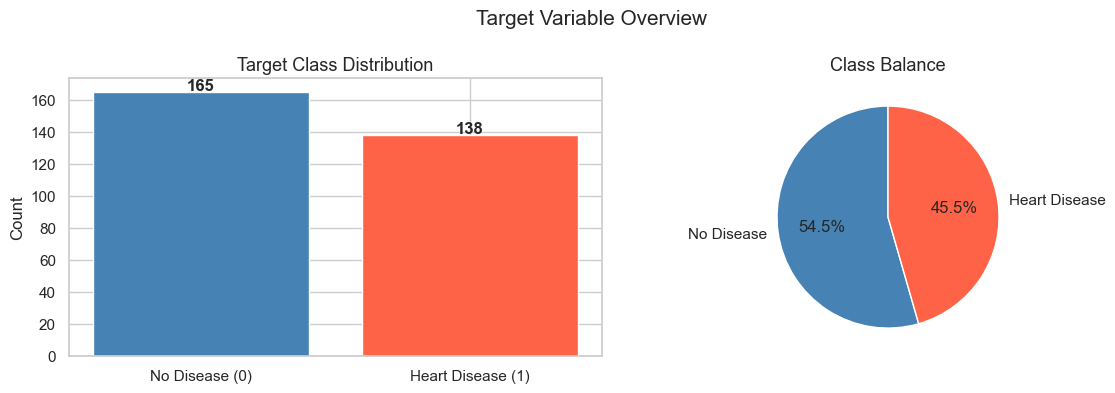

Class balance  →  0: 138  |  1: 165  |  Ratio: 1.20


In [30]:
# ── Target distribution ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['target'].value_counts()
axes[0].bar(['No Disease (0)', 'Heart Disease (1)'], counts.values,
            color=['steelblue', 'tomato'], edgecolor='white')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')
axes[0].set_title('Target Class Distribution', fontsize=13)
axes[0].set_ylabel('Count')

axes[1].pie(counts.values, labels=['No Disease', 'Heart Disease'],
            colors=['steelblue', 'tomato'], autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Class Balance', fontsize=13)

plt.suptitle('Target Variable Overview', fontsize=15)
plt.tight_layout()
plt.show()
print(f'Class balance  →  0: {counts[0]}  |  1: {counts[1]}  |  Ratio: {counts[1]/counts[0]:.2f}')

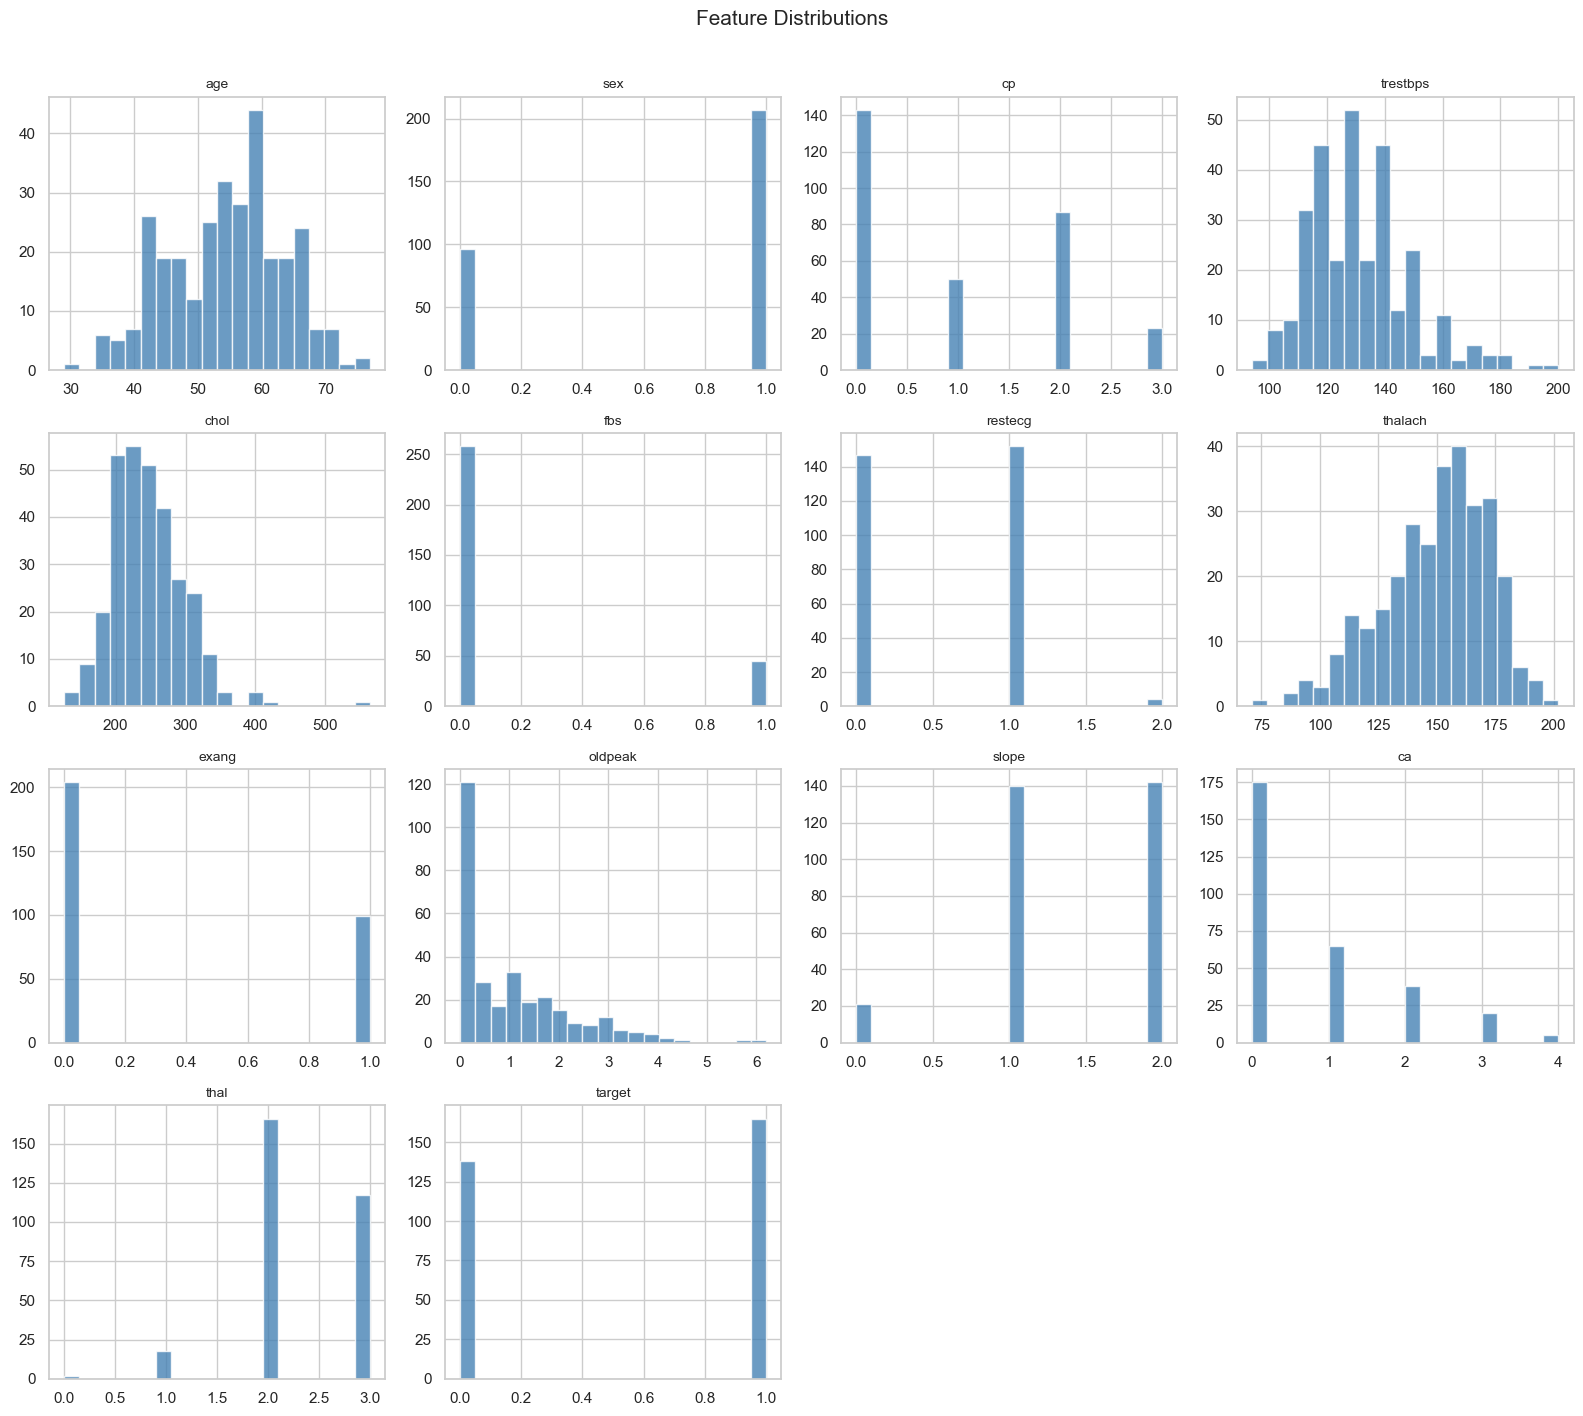

In [31]:
# ── Histograms for all features ─────────────────────────────────────────────
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()
for i, col in enumerate(df.columns):
    df[col].hist(ax=axes[i], bins=20, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Feature Distributions', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

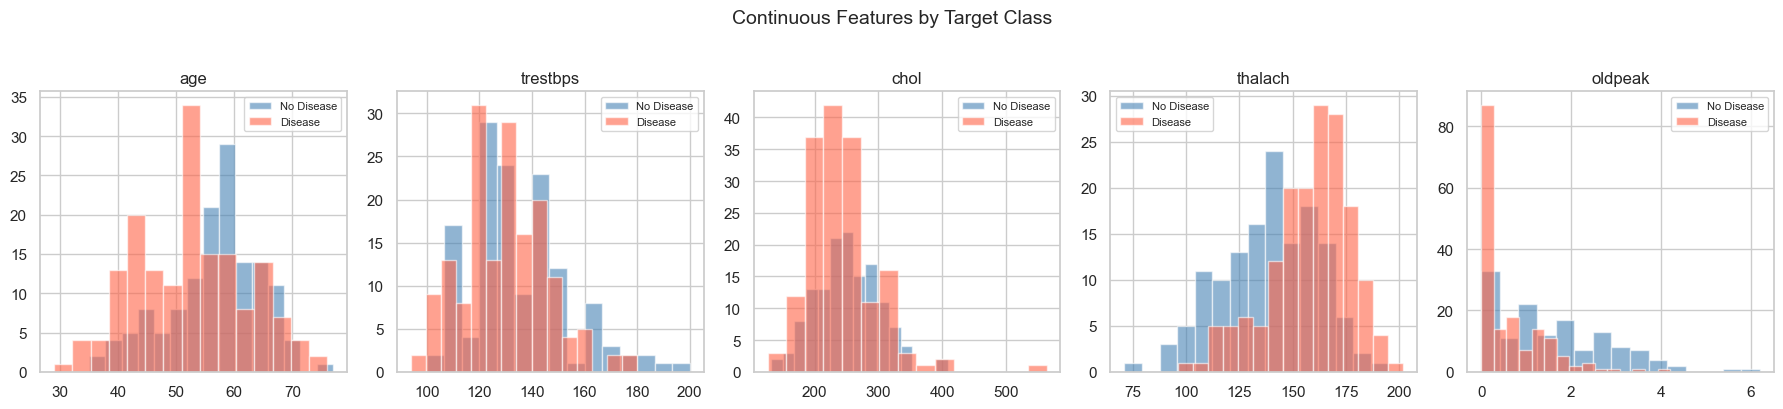

In [32]:
# ── Feature distributions split by target ──────────────────────────────────
continuous = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
fig, axes = plt.subplots(1, len(continuous), figsize=(18, 4))
for ax, col in zip(axes, continuous):
    for val, label, color in [(0, 'No Disease', 'steelblue'), (1, 'Disease', 'tomato')]:
        ax.hist(df[df['target'] == val][col], bins=15, alpha=0.6,
                label=label, color=color, edgecolor='white')
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.suptitle('Continuous Features by Target Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

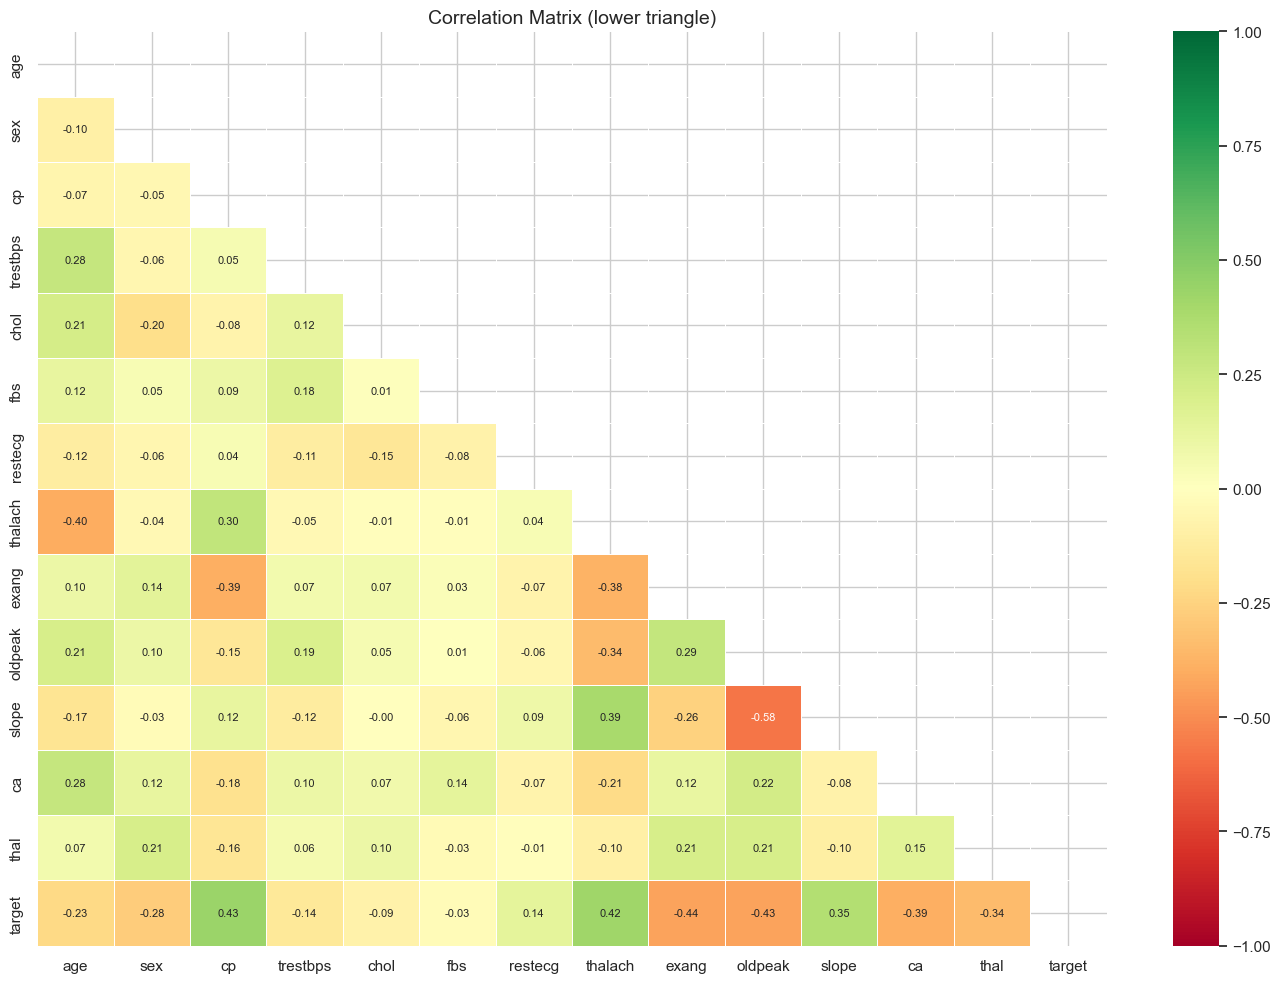


Top features correlated with target:
exang       0.436757
cp          0.433798
oldpeak     0.430696
thalach     0.421741
ca          0.391724
slope       0.345877
thal        0.344029
sex         0.280937
age         0.225439
trestbps    0.144931
restecg     0.137230
chol        0.085239
fbs         0.028046
Name: target, dtype: float64


In [33]:
# ── Correlation heatmap ─────────────────────────────────────────────────────
plt.figure(figsize=(14, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', linewidths=0.5,
            annot_kws={'size': 8}, vmin=-1, vmax=1)
plt.title('Correlation Matrix (lower triangle)', fontsize=14)
plt.tight_layout()
plt.show()

# Top correlations with target
print('\nTop features correlated with target:')
print(corr['target'].drop('target').abs().sort_values(ascending=False))

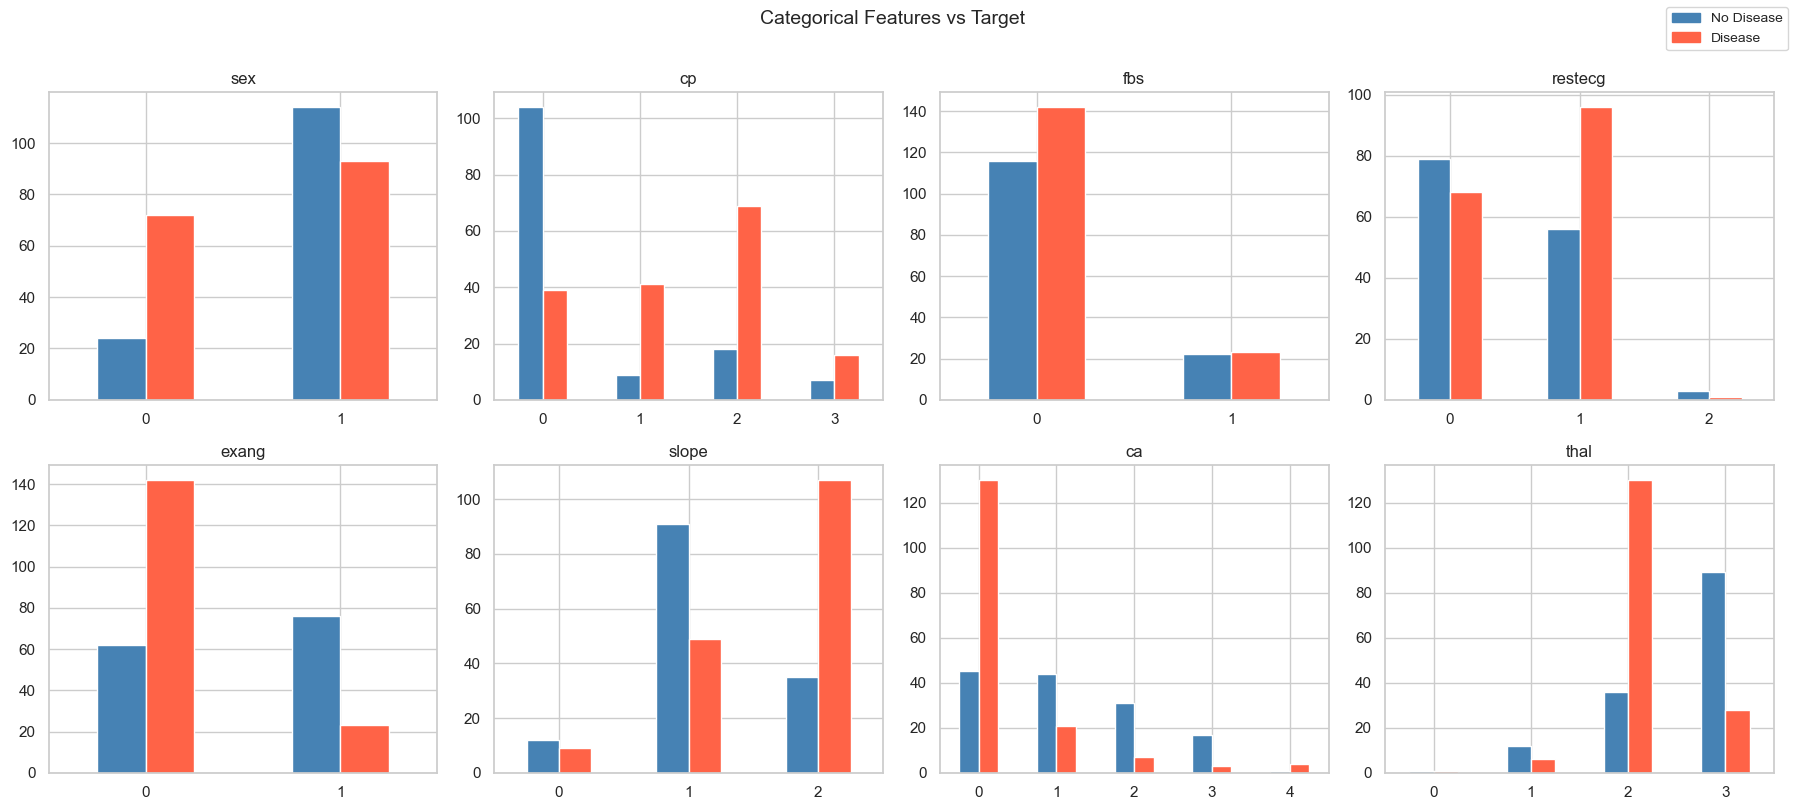

In [34]:
# ── Categorical features vs target ─────────────────────────────────────────
cat_feats = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for ax, col in zip(axes, cat_feats):
    ct = df.groupby([col, 'target']).size().unstack(fill_value=0)
    ct.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'],
            edgecolor='white', legend=False)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)
handles = [plt.Rectangle((0,0),1,1, color=c) for c in ['steelblue', 'tomato']]
fig.legend(handles, ['No Disease', 'Disease'], loc='upper right', fontsize=10)
plt.suptitle('Categorical Features vs Target', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

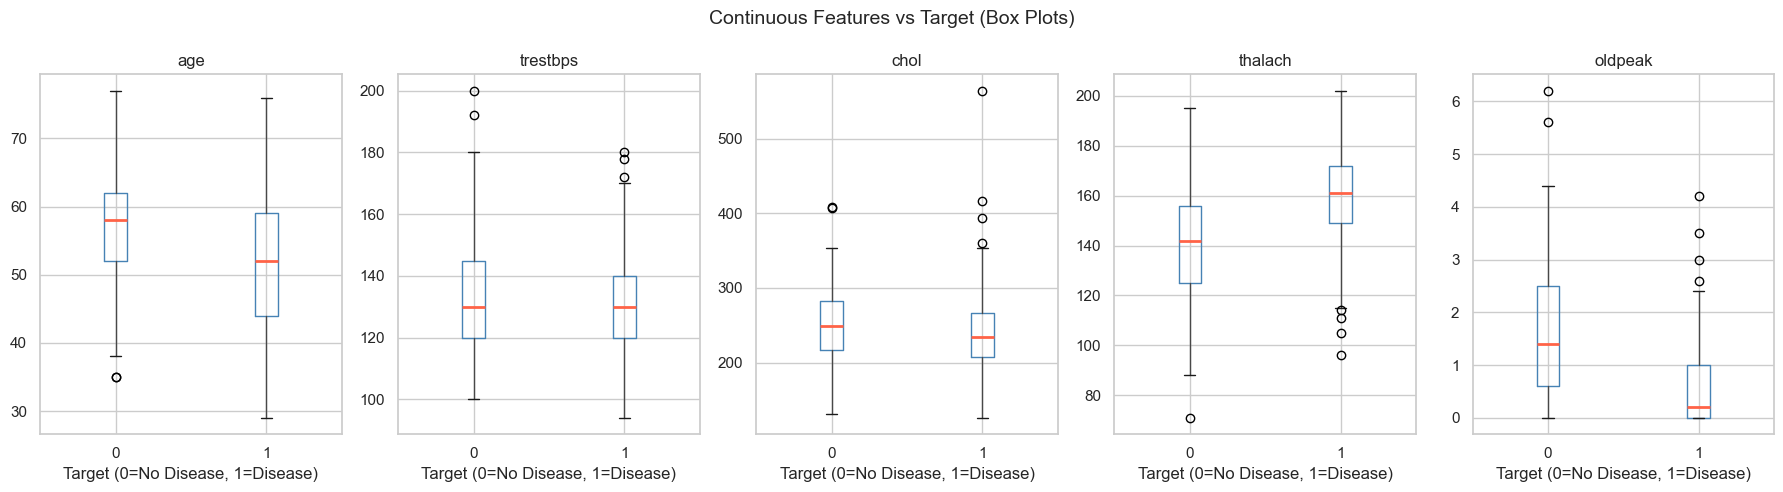

In [35]:
# ── Box plots: continuous features vs target ────────────────────────────────
fig, axes = plt.subplots(1, len(continuous), figsize=(18, 5))
for ax, col in zip(axes, continuous):
    df.boxplot(column=col, by='target', ax=ax,
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='tomato', linewidth=2))
    ax.set_title(col)
    ax.set_xlabel('Target (0=No Disease, 1=Disease)')
plt.suptitle('Continuous Features vs Target (Box Plots)', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Feature Engineering — Encoding & Scaling

In [36]:
# One-Hot Encode categorical columns
cat_to_encode = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
dataset = pd.get_dummies(df, columns=cat_to_encode)

print('Shape after encoding:', dataset.shape)
print('Columns:', dataset.columns.tolist())

Shape after encoding: (303, 31)
Columns: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'target', 'sex_0', 'sex_1', 'cp_0', 'cp_1', 'cp_2', 'cp_3', 'fbs_0', 'fbs_1', 'restecg_0', 'restecg_1', 'restecg_2', 'exang_0', 'exang_1', 'slope_0', 'slope_1', 'slope_2', 'ca_0', 'ca_1', 'ca_2', 'ca_3', 'ca_4', 'thal_0', 'thal_1', 'thal_2', 'thal_3']


In [37]:
# Scale continuous features
scaler = StandardScaler()
cols_to_scale = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
dataset[cols_to_scale] = scaler.fit_transform(dataset[cols_to_scale])

print('Sample after scaling:')
display(dataset.head(3))

Sample after scaling:


,age,trestbps,chol,thalach,oldpeak,target,sex_0,sex_1,cp_0,cp_1,...,slope_2,ca_0,ca_1,ca_2,ca_3,ca_4,thal_0,thal_1,thal_2,thal_3
0,0.952197,0.763956,-0.256334,0.015443,1.087338,1,False,True,False,False,...,False,True,False,False,False,False,False,True,False,False
1,-1.915313,-0.092738,0.072199,1.633471,2.122573,1,False,True,False,False,...,False,True,False,False,False,False,False,False,True,False
2,-1.474158,-0.092738,-0.816773,0.977514,0.310912,1,True,False,False,True,...,True,True,False,False,False,False,False,False,True,False


## 6. Train / Validation / Test Split

In [38]:
X = dataset.drop('target', axis=1)
y = dataset['target']

# 70 / 15 / 15 stratified split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp)

print(f'Train : {X_train.shape[0]} rows  |  class balance: {y_train.mean():.2%} positive')
print(f'Val   : {X_val.shape[0]} rows  |  class balance: {y_val.mean():.2%} positive')
print(f'Test  : {X_test.shape[0]} rows  |  class balance: {y_test.mean():.2%} positive')

Train : 212 rows  |  class balance: 54.25% positive
Val   : 45 rows  |  class balance: 55.56% positive
Test  : 46 rows  |  class balance: 54.35% positive


## 7. Baseline — Multiple Model Evaluation (Cross-Validation)

In [39]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

models = {
    'KNN (k=12)'               : KNeighborsClassifier(n_neighbors=12),
    'Decision Tree (depth=3)'  : DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE),
    'Random Forest (n=90)'     : RandomForestClassifier(n_estimators=90, random_state=RANDOM_STATE),
    'Logistic Regression'      : LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'SVM'                      : SVC(probability=True, random_state=RANDOM_STATE),
    'Naive Bayes'              : GaussianNB(),
    'Gradient Boosting'        : GradientBoostingClassifier(random_state=RANDOM_STATE),
    'Extra Trees'              : ExtraTreesClassifier(random_state=RANDOM_STATE),
}

results = {}
print(f'{"Model":<30}  {"CV Acc (mean)":>14}  {"Std":>8}')
print('-' * 58)
for name, mdl in models.items():
    scores = cross_val_score(mdl, X_train, y_train, cv=cv, scoring='accuracy')
    results[name] = scores
    print(f'{name:<30}  {scores.mean()*100:>12.2f}%  {scores.std()*100:>6.2f}%')

Model                            CV Acc (mean)       Std
----------------------------------------------------------
KNN (k=12)                             83.07%    6.57%
Decision Tree (depth=3)                77.86%    8.11%
Random Forest (n=90)                   86.36%    4.30%
Logistic Regression                    85.45%    7.23%
SVM                                    85.41%    4.83%
Naive Bayes                            75.52%    8.49%
Gradient Boosting                      83.05%    4.69%
Extra Trees                            84.96%    6.49%


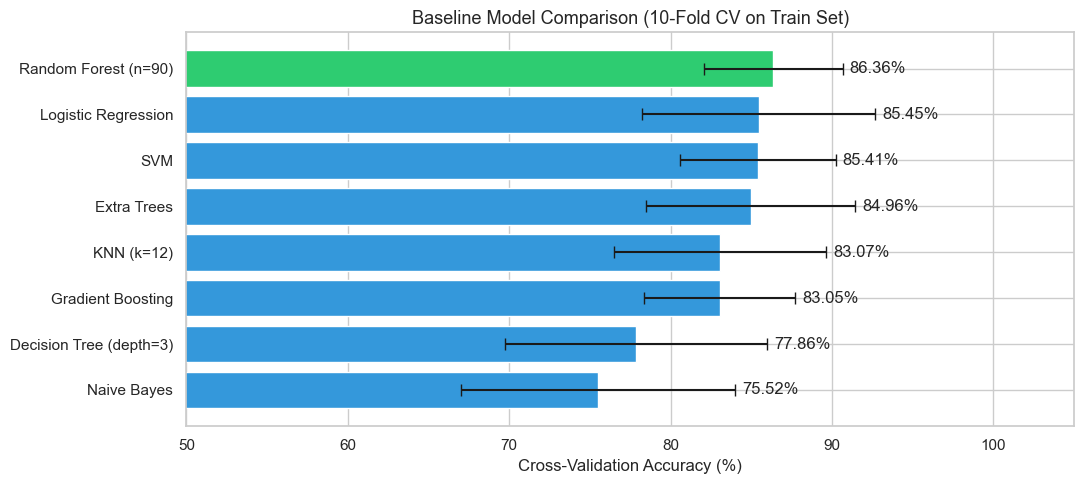

In [40]:
# Visual comparison
means = {k: v.mean()*100 for k, v in results.items()}
stds  = {k: v.std()*100  for k, v in results.items()}
sorted_models = sorted(means, key=means.get, reverse=True)

fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(sorted_models))]
bars = ax.barh(sorted_models,
               [means[m] for m in sorted_models],
               xerr=[stds[m] for m in sorted_models],
               color=colors, capsize=4, edgecolor='white')
ax.bar_label(bars, fmt='%.2f%%', padding=5)
ax.set_xlabel('Cross-Validation Accuracy (%)')
ax.set_title('Baseline Model Comparison (10-Fold CV on Train Set)', fontsize=13)
ax.set_xlim(50, 105)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 8. Hyperparameter Tuning — Top Models

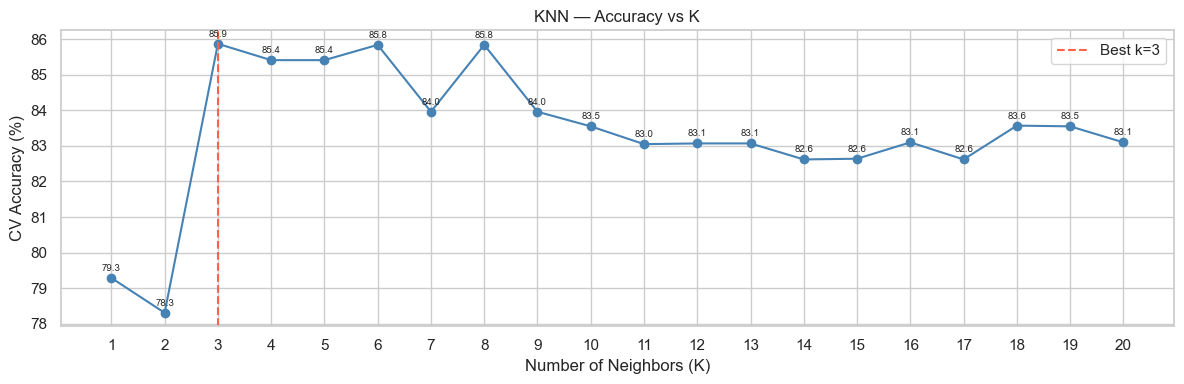

Best K=3  →  CV Accuracy: 85.87%


In [41]:
# ── Tune KNN ────────────────────────────────────────────────────────────────
knn_scores = []
k_range = range(1, 21)
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(knn, X_train, y_train, cv=cv, scoring='accuracy').mean()
    knn_scores.append(round(score, 4))

best_k = k_range[np.argmax(knn_scores)]

plt.figure(figsize=(12, 4))
plt.plot(list(k_range), [s*100 for s in knn_scores], 'o-', color='steelblue')
plt.axvline(best_k, color='tomato', linestyle='--', label=f'Best k={best_k}')
for k, s in zip(k_range, knn_scores):
    plt.text(k, s*100 + 0.2, f'{s*100:.1f}', ha='center', fontsize=7)
plt.xticks(list(k_range))
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('CV Accuracy (%)')
plt.title('KNN — Accuracy vs K')
plt.legend()
plt.tight_layout()
plt.show()
print(f'Best K={best_k}  →  CV Accuracy: {max(knn_scores)*100:.2f}%')

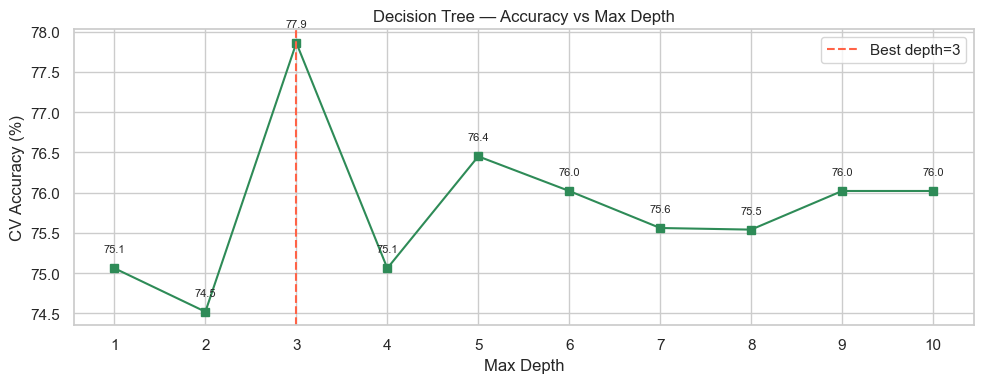

Best depth=3  →  CV Accuracy: 77.86%


In [42]:
# ── Tune Decision Tree ──────────────────────────────────────────────────────
dt_scores = []
depth_range = range(1, 11)
for d in depth_range:
    dt = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    score = cross_val_score(dt, X_train, y_train, cv=cv, scoring='accuracy').mean()
    dt_scores.append(round(score, 4))

best_depth = list(depth_range)[np.argmax(dt_scores)]

plt.figure(figsize=(10, 4))
plt.plot(list(depth_range), [s*100 for s in dt_scores], 's-', color='seagreen')
plt.axvline(best_depth, color='tomato', linestyle='--', label=f'Best depth={best_depth}')
for d, s in zip(depth_range, dt_scores):
    plt.text(d, s*100 + 0.2, f'{s*100:.1f}', ha='center', fontsize=8)
plt.xticks(list(depth_range))
plt.xlabel('Max Depth')
plt.ylabel('CV Accuracy (%)')
plt.title('Decision Tree — Accuracy vs Max Depth')
plt.legend()
plt.tight_layout()
plt.show()
print(f'Best depth={best_depth}  →  CV Accuracy: {max(dt_scores)*100:.2f}%')

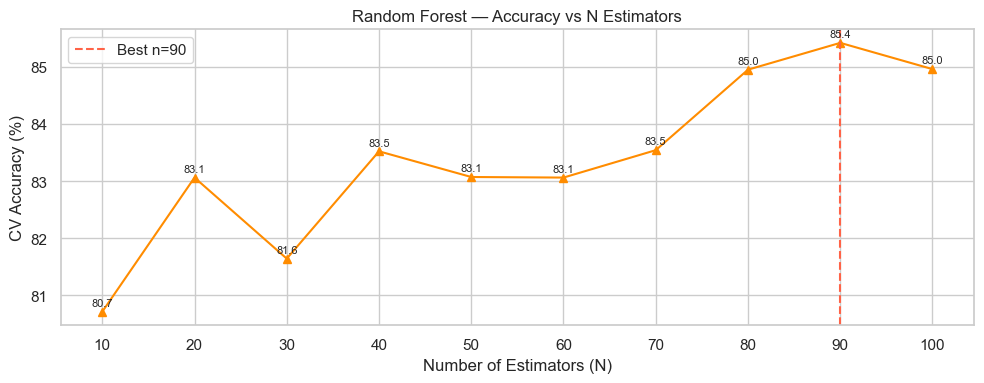

Best N=90  →  CV Accuracy: 85.42%


In [43]:
# ── Tune Random Forest ──────────────────────────────────────────────────────
forest_scores = []
n_range = range(10, 101, 10)
for n in n_range:
    rf = RandomForestClassifier(n_estimators=n, random_state=RANDOM_STATE)
    score = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy').mean()
    forest_scores.append(round(score, 4))

best_n = list(n_range)[np.argmax(forest_scores)]

plt.figure(figsize=(10, 4))
plt.plot(list(n_range), [s*100 for s in forest_scores], '^-', color='darkorange')
plt.axvline(best_n, color='tomato', linestyle='--', label=f'Best n={best_n}')
for n, s in zip(n_range, forest_scores):
    plt.text(n, s*100 + 0.1, f'{s*100:.1f}', ha='center', fontsize=8)
plt.xticks(list(n_range))
plt.xlabel('Number of Estimators (N)')
plt.ylabel('CV Accuracy (%)')
plt.title('Random Forest — Accuracy vs N Estimators')
plt.legend()
plt.tight_layout()
plt.show()
print(f'Best N={best_n}  →  CV Accuracy: {max(forest_scores)*100:.2f}%')

In [44]:
# ── GridSearchCV on Gradient Boosting ──────────────────────────────────────
gb_params = {
    'n_estimators'  : [50, 100, 200],
    'learning_rate' : [0.05, 0.1, 0.2],
    'max_depth'     : [2, 3, 4]
}
gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    gb_params, cv=5, scoring='accuracy', n_jobs=-1
)
gb_grid.fit(X_train, y_train)
print('Best GB params :', gb_grid.best_params_)
print('Best CV Acc    :', round(gb_grid.best_score_*100, 2), '%')
best_gb = gb_grid.best_estimator_

Best GB params : {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100}
Best CV Acc    : 84.97 %


## 9. Overfitting Check — Learning Curves

All models fitted ✓


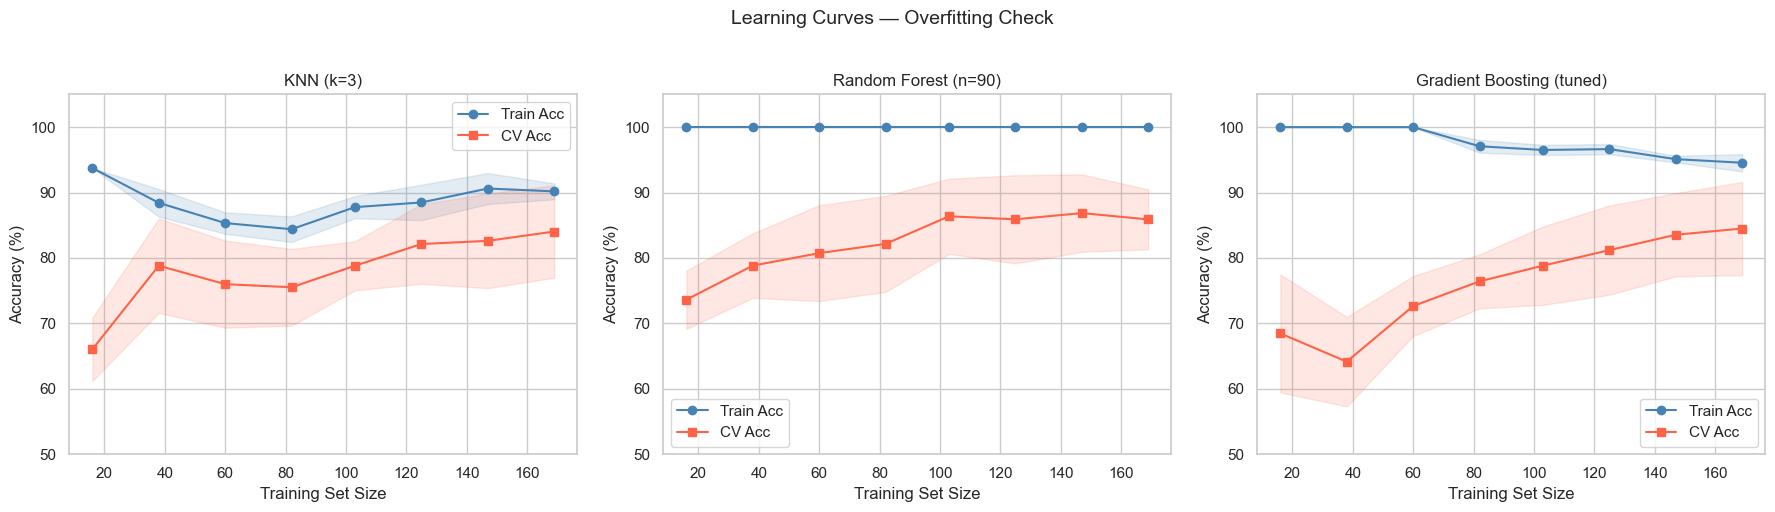

In [45]:
def plot_learning_curve(model, X, y, title, ax):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=5, scoring='accuracy',
        train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1
    )
    tr_mean = train_scores.mean(axis=1) * 100
    vl_mean = val_scores.mean(axis=1) * 100
    tr_std  = train_scores.std(axis=1)  * 100
    vl_std  = val_scores.std(axis=1)   * 100

    ax.plot(train_sizes, tr_mean, 'o-', label='Train Acc',  color='steelblue')
    ax.plot(train_sizes, vl_mean, 's-', label='CV Acc',     color='tomato')
    ax.fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std, alpha=0.15, color='steelblue')
    ax.fill_between(train_sizes, vl_mean - vl_std, vl_mean + vl_std, alpha=0.15, color='tomato')
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('Accuracy (%)')
    ax.set_title(title)
    ax.legend()
    ax.set_ylim(50, 105)

# Instantiate tuned models
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_rf  = RandomForestClassifier(n_estimators=best_n, random_state=RANDOM_STATE)
best_dt  = DecisionTreeClassifier(max_depth=best_depth, random_state=RANDOM_STATE)

# Fit ALL models on training data so they are ready for later cells
for mdl in [best_knn, best_rf, best_dt, best_gb]:
    mdl.fit(X_train, y_train)
print('All models fitted ✓')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_learning_curve(best_knn, X_train, y_train, f'KNN (k={best_k})',           axes[0])
plot_learning_curve(best_rf,  X_train, y_train, f'Random Forest (n={best_n})', axes[1])
plot_learning_curve(best_gb,  X_train, y_train, 'Gradient Boosting (tuned)',   axes[2])
plt.suptitle('Learning Curves — Overfitting Check', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [46]:
# Numeric train vs val gap check
for name, mdl in [('KNN', best_knn), ('RandomForest', best_rf), ('GradientBoosting', best_gb)]:
    mdl.fit(X_train, y_train)
    tr_acc = accuracy_score(y_train, mdl.predict(X_train)) * 100
    vl_acc = accuracy_score(y_val,   mdl.predict(X_val))   * 100
    gap    = tr_acc - vl_acc
    status = '⚠️ overfitting' if gap > 10 else '✓ acceptable'
    print(f'{name:<20}  Train={tr_acc:.1f}%  Val={vl_acc:.1f}%  Gap={gap:+.1f}%  {status}')

KNN                   Train=89.6%  Val=80.0%  Gap=+9.6%  ✓ acceptable
RandomForest          Train=100.0%  Val=73.3%  Gap=+26.7%  ⚠️ overfitting
GradientBoosting      Train=92.5%  Val=80.0%  Gap=+12.5%  ⚠️ overfitting


## 10. Feature Importance & Interpretation

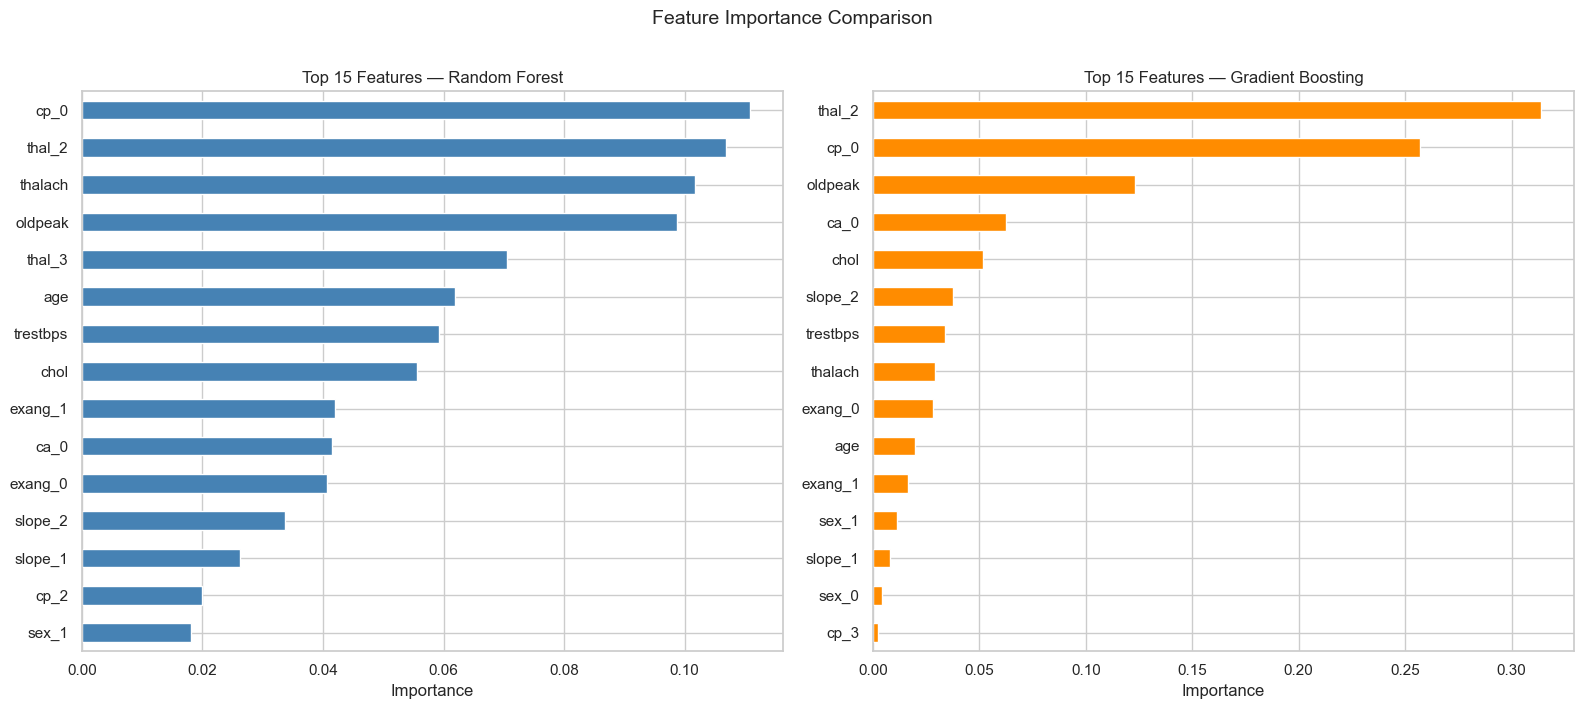

In [47]:
# Feature importances from Random Forest & Gradient Boosting
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, mdl, title, color in [
    (axes[0], best_rf,  'Random Forest',        'steelblue'),
    (axes[1], best_gb,  'Gradient Boosting',     'darkorange')
]:
    imp = pd.Series(mdl.feature_importances_, index=X_train.columns)
    imp.nlargest(15).sort_values().plot(kind='barh', ax=ax, color=color)
    ax.set_title(f'Top 15 Features — {title}', fontsize=12)
    ax.set_xlabel('Importance')

plt.suptitle('Feature Importance Comparison', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 11. Advanced Ensemble Methods

In [48]:
# ── Voting Classifier (soft voting) ────────────────────────────────────────
voting_clf = VotingClassifier(
    estimators=[
        ('rf',  RandomForestClassifier(n_estimators=best_n, random_state=RANDOM_STATE)),
        ('gb',  GradientBoostingClassifier(**gb_grid.best_params_, random_state=RANDOM_STATE)),
        ('lr',  LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ],
    voting='soft'
)
voting_clf.fit(X_train, y_train)
vote_acc = accuracy_score(y_val, voting_clf.predict(X_val)) * 100
print(f'VotingClassifier  Val Accuracy: {vote_acc:.2f}%')

VotingClassifier  Val Accuracy: 82.22%


In [49]:
# ── Stacking Classifier ─────────────────────────────────────────────────────
stacking_clf = StackingClassifier(
    estimators=[
        ('rf',  RandomForestClassifier(n_estimators=best_n, random_state=RANDOM_STATE)),
        ('gb',  GradientBoostingClassifier(**gb_grid.best_params_, random_state=RANDOM_STATE)),
        ('knn', KNeighborsClassifier(n_neighbors=best_k))
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5, n_jobs=-1
)
stacking_clf.fit(X_train, y_train)
stack_acc = accuracy_score(y_val, stacking_clf.predict(X_val)) * 100
print(f'StackingClassifier Val Accuracy: {stack_acc:.2f}%')

StackingClassifier Val Accuracy: 77.78%


In [50]:
# ── Ensemble summary ────────────────────────────────────────────────────────
ens_results = {
    'KNN (best k)'            : accuracy_score(y_val, best_knn.predict(X_val)) * 100,
    'Decision Tree (tuned)'   : accuracy_score(y_val, best_dt.predict(X_val))  * 100,
    'Random Forest (tuned)'   : accuracy_score(y_val, best_rf.predict(X_val))  * 100,
    'Gradient Boosting (tuned)': accuracy_score(y_val, best_gb.predict(X_val)) * 100,
    'VotingClassifier'        : vote_acc,
    'StackingClassifier'      : stack_acc,
}

ens_df = pd.Series(ens_results).sort_values(ascending=False)
print('\nVal Accuracy Summary:')
for name, acc in ens_df.items():
    print(f'  {name:<30}: {acc:.2f}%')

best_model_name = ens_df.idxmax()
best_model_map  = {
    'KNN (best k)'            : best_knn,
    'Decision Tree (tuned)'   : best_dt,
    'Random Forest (tuned)'   : best_rf,
    'Gradient Boosting (tuned)': best_gb,
    'VotingClassifier'        : voting_clf,
    'StackingClassifier'      : stacking_clf,
}
best_model = best_model_map[best_model_name]
print(f'\n→ Best model: {best_model_name}')


Val Accuracy Summary:
  Decision Tree (tuned)         : 84.44%
  VotingClassifier              : 82.22%
  KNN (best k)                  : 80.00%
  Gradient Boosting (tuned)     : 80.00%
  StackingClassifier            : 77.78%
  Random Forest (tuned)         : 73.33%

→ Best model: Decision Tree (tuned)


## 12. Final Evaluation on Hold-Out Test Set

In [51]:
y_pred      = best_model.predict(X_test)
y_prob      = best_model.predict_proba(X_test)[:, 1] \
              if hasattr(best_model, 'predict_proba') else None

test_acc    = accuracy_score(y_test, y_pred) * 100
test_roc    = roc_auc_score(y_test, y_prob) if y_prob is not None else None

print('=' * 52)
print(f'  Hold-Out Test Results: {best_model_name}')
print('=' * 52)
print(f'  Accuracy : {test_acc:.2f}%')
if test_roc:
    print(f'  ROC-AUC  : {test_roc:.4f}')
print('=' * 52)
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Heart Disease']))

  Hold-Out Test Results: Decision Tree (tuned)
  Accuracy : 76.09%
  ROC-AUC  : 0.7438

Classification Report:
               precision    recall  f1-score   support

   No Disease       0.75      0.71      0.73        21
Heart Disease       0.77      0.80      0.78        25

     accuracy                           0.76        46
    macro avg       0.76      0.76      0.76        46
 weighted avg       0.76      0.76      0.76        46



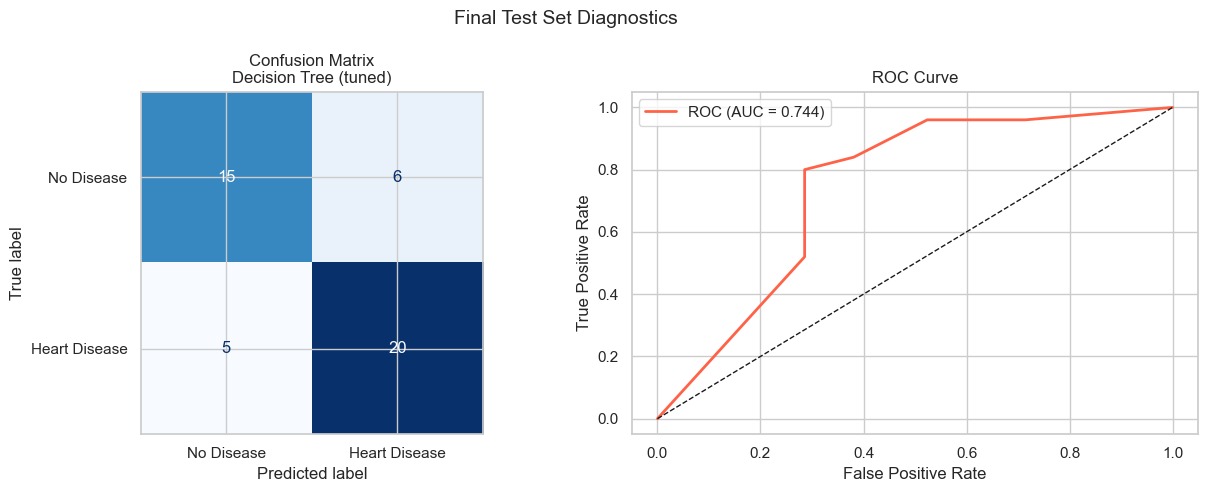

In [52]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Disease', 'Heart Disease'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Confusion Matrix\n{best_model_name}', fontsize=12)

# ROC Curve
if y_prob is not None:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[1].plot(fpr, tpr, color='tomato', lw=2,
                 label=f'ROC (AUC = {test_roc:.3f})')
    axes[1].plot([0,1],[0,1], 'k--', lw=1)
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('ROC Curve')
    axes[1].legend()
else:
    axes[1].set_visible(False)

plt.suptitle('Final Test Set Diagnostics', fontsize=14)
plt.tight_layout()
plt.show()

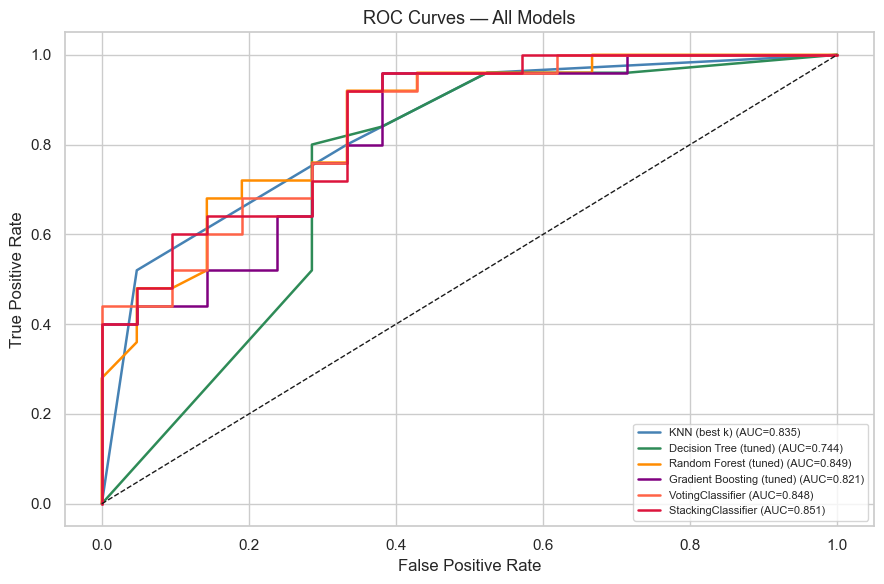

In [53]:
# ROC curves for all tuned models
plt.figure(figsize=(9, 6))
model_colors = ['steelblue','seagreen','darkorange','purple','tomato','crimson']

for (name, mdl), color in zip(best_model_map.items(), model_colors):
    if hasattr(mdl, 'predict_proba'):
        prob = mdl.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, prob)
        auc = roc_auc_score(y_test, prob)
        plt.plot(fpr, tpr, lw=1.8, color=color, label=f'{name} (AUC={auc:.3f})')

plt.plot([0,1],[0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models', fontsize=13)
plt.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

## 13. Summary

In [54]:
print('╔══════════════════════════════════════════════════════╗')
print(f'║  BEST MODEL: {best_model_name:<41}║')
print('╠══════════════════════════════════════════════════════╣')
print(f'║  Test Accuracy : {test_acc:.2f}%{" "*33}║')
if test_roc:
    print(f'║  ROC-AUC       : {test_roc:.4f}{" "*32}║')
print('╚══════════════════════════════════════════════════════╝')

print('''
Pipeline steps completed:
  ✓ Loaded and understood the data (303 rows × 14 cols)
  ✓ Handled missing values (median/mode imputation)
  ✓ Explored data with histograms, box plots, count plots, heatmap
  ✓ One-Hot Encoded categorical features, scaled continuous ones
  ✓ Stratified 70/15/15 train / val / test split
  ✓ Evaluated 8 baseline models with 10-fold stratified CV
  ✓ Tuned KNN (k sweep), Decision Tree (depth sweep),
    Random Forest (n sweep), Gradient Boosting (GridSearchCV)
  ✓ Checked overfitting via learning curves + train/val gap
  ✓ Plotted feature importances (RF & GB)
  ✓ Built Voting & Stacking ensembles
  ✓ Final evaluation: accuracy, ROC-AUC, confusion matrix,
    classification report, multi-model ROC curves
''')

╔══════════════════════════════════════════════════════╗
║  BEST MODEL: Decision Tree (tuned)                    ║
╠══════════════════════════════════════════════════════╣
║  Test Accuracy : 76.09%                                 ║
║  ROC-AUC       : 0.7438                                ║
╚══════════════════════════════════════════════════════╝

Pipeline steps completed:
  ✓ Loaded and understood the data (303 rows × 14 cols)
  ✓ Handled missing values (median/mode imputation)
  ✓ Explored data with histograms, box plots, count plots, heatmap
  ✓ One-Hot Encoded categorical features, scaled continuous ones
  ✓ Stratified 70/15/15 train / val / test split
  ✓ Evaluated 8 baseline models with 10-fold stratified CV
  ✓ Tuned KNN (k sweep), Decision Tree (depth sweep),
    Random Forest (n sweep), Gradient Boosting (GridSearchCV)
  ✓ Checked overfitting via learning curves + train/val gap
  ✓ Plotted feature importances (RF & GB)
  ✓ Built Voting & Stacking ensembles
  ✓ Final evaluation: